In [1]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import optuna
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from xgboost import XGBRegressor
from Preprocess import preprocess_data_window
from catboost import CatBoostRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)

c:\Users\kaitl\OneDrive\Documents\Icequake Modeling\Code\Icequake-QRC-\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Cell 2: Load data ────────────────────────────────────────────────────────
data_orig     = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")

In [4]:
# ── Cell 3: Preprocessing ────────────────────────────────────────────────────
n_previous_events = 20
n_qubits_base = 6

X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = preprocess_data_window(
    filtered_time, data_orig, n_previous_events
)

rn = np.random.default_rng(seed=42) 

def maybe_subset_split(
    X: np.ndarray,
    y: np.ndarray,
    frac: float,
    rng: np.random.Generator,
) :
    if frac >= 1.0:
        return X, y
    n = len(X)
    if n == 0:
        return X, y
    keep = max(1, int(n * frac))
    idx = rng.choice(n, size=keep, replace=False)
    idx.sort()
    return X[idx], y[idx]
X_train, y_train = maybe_subset_split(X_train, y_train, frac=0.1, rng=rn)
X_val, y_val = maybe_subset_split(X_train, y_train, frac=0.1, rng=rn)
X_test, y_test = maybe_subset_split(X_train, y_train, frac=0.1, rng=rn)


print("NaN count per column:\n", X_train.isna().sum())
print("Total NaN:", X_train.isna().sum().sum())

X shape:  (2822, 126)
y shape:  (2822,)


KeyError: "None of [Index([  11,   51,   57,   61,   69,   97,   99,  106,  121,  130,\n       ...\n       1579, 1584, 1605, 1606, 1634, 1635, 1648, 1655, 1677, 1690],\n      dtype='int64', length=169)] are in the [columns]"

In [ ]:
# ── Cell 4: Config ───────────────────────────────────────────────────────────
QRC_CONFIG = {
    "num_layers_per_event": 2,
    "shots": 5, #put back at 4096 for true best 
    "n_iterations": 5,
    "top_k": 3,
    "correlation_threshold": 0.0,
    "random_seed": 42,
}

CLASSICAL_MODEL_NAME = "XGBoost"
n_previous_events = 20
SHORT_THRESHOLD = 65_000

print("QRC Config:", QRC_CONFIG)
print("Classical model:", CLASSICAL_MODEL_NAME)
print(f"Regime boundary: {SHORT_THRESHOLD}s")

QRC Config: {'num_layers_per_event': 2, 'shots': 4096, 'n_iterations': 5, 'top_k': 3, 'correlation_threshold': 0.0, 'random_seed': 42}
Classical model: XGBoost
Regime boundary: 65000s


In [ ]:
# ── Cell 5+6: Scaling ─────────────────────────────────────────────────────────
def scale_to_pi_range(X_train, X_val, X_test):
    train_min = X_train.min(axis=0)
    train_max = X_train.max(axis=0)
    denom = train_max - train_min
    denom[denom == 0] = 1.0

    def transform(X):
        scaled = (X - train_min) / denom
        scaled = np.clip(scaled, 0.0, 1.0)
        return scaled * np.pi

    return transform(X_train), transform(X_val), transform(X_test)


X_train_sel = X_train.to_numpy()
X_val_sel   = X_val.to_numpy()
X_test_sel  = X_test.to_numpy()

X_train_q, X_val_q, X_test_q = scale_to_pi_range(X_train_sel, X_val_sel, X_test_sel)

# Convert targets to numpy once here for use throughout
y_train_np = y_train.to_numpy() if hasattr(y_train, "to_numpy") else np.array(y_train)
y_val_np   = y_val.to_numpy()   if hasattr(y_val,   "to_numpy") else np.array(y_val)
y_test_np  = y_test.to_numpy()  if hasattr(y_test,  "to_numpy") else np.array(y_test)

n_qubits       = n_qubits_base
n_states       = 2 ** n_qubits
n_total_events = n_previous_events + 1

print(f"Input to quantum circuit: {X_train_q.shape}")
print(f"n_qubits: {n_qubits}, n_states: {n_states}")
print(f"Total events per sample: {n_total_events}")

Input to quantum circuit: (1692, 126)
n_qubits: 6, n_states: 64
Total events per sample: 21


In [ ]:
# ── Cell 5b: Train classifier on scaled classical features ────────────────────
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

y_clf_train = (y_train_np >= SHORT_THRESHOLD).astype(int)
y_clf_val   = (y_val_np   >= SHORT_THRESHOLD).astype(int)
y_clf_test  = (y_test_np  >= SHORT_THRESHOLD).astype(int)

print(f"Class distribution (train) — Short: {(y_clf_train==0).sum()}, Long: {(y_clf_train==1).sum()}")
print(f"Class distribution (val)   — Short: {(y_clf_val==0).sum()},   Long: {(y_clf_val==1).sum()}")
print(f"Class distribution (test)  — Short: {(y_clf_test==0).sum()},  Long: {(y_clf_test==1).sum()}")

sample_weights_clf = compute_sample_weight("balanced", y_clf_train)

def clf_objective(trial):
    clf = XGBClassifier(
        objective="binary:logistic",
        n_estimators=500,
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 6),
        subsample=trial.suggest_float("subsample", 0.6, 0.9),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 0.9),
        scale_pos_weight=trial.suggest_float("scale_pos_weight", 0.5, 3.0),
        random_state=42,
        eval_metric="logloss",
    )
    clf.fit(
        X_train_q, y_clf_train,
        sample_weight=sample_weights_clf,
        eval_set=[(X_val_q, y_clf_val)],
        verbose=False,
    )
    preds = clf.predict(X_val_q)
    return 1.0 - accuracy_score(y_clf_val, preds)

clf_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
clf_study.optimize(clf_objective, n_trials=30)

slip_classifier = XGBClassifier(
    objective="binary:logistic",
    n_estimators=500,
    **clf_study.best_params,
    random_state=42,
    eval_metric="logloss",
)
slip_classifier.fit(
    X_train_q, y_clf_train,
    sample_weight=sample_weights_clf,
    eval_set=[(X_val_q, y_clf_val)],
    verbose=False,
)

clf_train_acc = accuracy_score(y_clf_train, slip_classifier.predict(X_train_q))
clf_val_acc   = accuracy_score(y_clf_val,   slip_classifier.predict(X_val_q))
clf_test_acc  = accuracy_score(y_clf_test,  slip_classifier.predict(X_test_q))

print(f"\nClassifier accuracy — Train: {clf_train_acc:.4f}, Val: {clf_val_acc:.4f}, Test: {clf_test_acc:.4f}")
print(f"\nClassification report (test):")
print(classification_report(y_clf_test, slip_classifier.predict(X_test_q),
                             target_names=["Short (<65k s)", "Long (>=65k s)"]))

# Pre-compute all regime masks and routing indices
short_mask_train = y_train_np < SHORT_THRESHOLD
long_mask_train  = ~short_mask_train
short_mask_val   = y_val_np < SHORT_THRESHOLD
long_mask_val    = ~short_mask_val

clf_test_labels = slip_classifier.predict(X_test_q)
clf_val_labels  = slip_classifier.predict(X_val_q)
short_test_idx  = np.where(clf_test_labels == 0)[0]
long_test_idx   = np.where(clf_test_labels == 1)[0]
short_val_idx   = np.where(clf_val_labels == 0)[0]
long_val_idx    = np.where(clf_val_labels == 1)[0]

print(f"\nTest routing — Short: {len(short_test_idx)}, Long: {len(long_test_idx)}")
print(f"Val routing  — Short: {len(short_val_idx)},  Long: {len(long_val_idx)}")

if clf_val_acc < 0.75:
    print(f"\nWARNING: Classifier val accuracy {clf_val_acc:.4f} is below 0.75.")
else:
    print(f"\nClassifier accuracy {clf_val_acc:.4f} is sufficient — proceeding.")

Class distribution (train) — Short: 1054, Long: 638
Class distribution (val)   — Short: 358,   Long: 207
Class distribution (test)  — Short: 367,  Long: 198

Classifier accuracy — Train: 1.0000, Val: 0.7965, Test: 0.8389

Classification report (test):
                precision    recall  f1-score   support

Short (<65k s)       0.88      0.88      0.88       367
Long (>=65k s)       0.77      0.77      0.77       198

      accuracy                           0.84       565
     macro avg       0.82      0.82      0.82       565
  weighted avg       0.84      0.84      0.84       565


Test routing — Short: 368, Long: 197
Val routing  — Short: 379,  Long: 186

Classifier accuracy 0.7965 is sufficient — proceeding.


In [ ]:
# ── Cell 7: FC-TFI Hamiltonian ────────────────────────────────────────────────
def generate_ising_params(n_qubits, rng, J_std=0.5, h=1.0, t=0.5):
    J = np.zeros((n_qubits, n_qubits))
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            J[i, j] = rng.normal(0, J_std)
    return J, h, t


def trotter_ising_layer(qc, n_qubits, J, h, t, n_trotter_steps=3):
    dt = t / n_trotter_steps
    for _ in range(n_trotter_steps):
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                if abs(J[i, j]) > 1e-10:
                    qc.cx(i, j)
                    qc.rz(2 * J[i, j] * dt, j)
                    qc.cx(i, j)
        for i in range(n_qubits):
            qc.rx(2 * h * dt, i)


def encode_rotations(qc, data_sample, n_qubits):
    for i in range(n_qubits):
        qc.ry(float(data_sample[i]), i)


def build_reservoir_circuit_rotations(data_sample, ising_params, num_layers, n_qubits):
    J, h, t = ising_params
    qc = QuantumCircuit(n_qubits)

    for i in range(n_qubits):
        qc.h(i)

    encode_rotations(qc, data_sample, n_qubits)
    qc.barrier()

    for layer in range(num_layers):
        trotter_ising_layer(qc, n_qubits, J, h, t)
        qc.barrier()

        encode_rotations(qc, data_sample, n_qubits)
        qc.barrier()

        trotter_ising_layer(qc, n_qubits, J, h, t)
        qc.barrier()

    return qc


def generate_random_angles(num_layers, n_qubits, rng):
    return generate_ising_params(n_qubits, rng)

In [ ]:
# ── Cell 8: Pauli runner — quantum features only, no classical concatenation ───
def get_pauli_expectations(circuit_base, n_qubits, shots, simulator):
    expectations = np.zeros(3 * n_qubits)

    for basis_idx, basis in enumerate(['Z', 'X', 'Y']):
        qc_meas = circuit_base.copy()

        if basis == 'X':
            for i in range(n_qubits):
                qc_meas.h(i)
        elif basis == 'Y':
            for i in range(n_qubits):
                qc_meas.sdg(i)
                qc_meas.h(i)

        qc_meas.measure_all()
        result = simulator.run(qc_meas, shots=shots).result()
        counts = result.get_counts()

        for bitstring, count in counts.items():
            bits = bitstring.replace(" ", "")
            for qubit_idx in range(n_qubits):
                bit = int(bits[n_qubits - 1 - qubit_idx])
                expectations[basis_idx * n_qubits + qubit_idx] += (
                    (1 - 2 * bit) * count / shots
                )

    zz_correlators = np.zeros(n_qubits)
    qc_zz = circuit_base.copy()
    qc_zz.measure_all()
    result_zz = simulator.run(qc_zz, shots=shots).result()
    counts_zz = result_zz.get_counts()

    for bitstring, count in counts_zz.items():
        bits = bitstring.replace(" ", "")
        for i in range(n_qubits):
            j = (i + 1) % n_qubits
            bit_i = int(bits[n_qubits - 1 - i])
            bit_j = int(bits[n_qubits - 1 - j])
            zz_correlators[i] += (
                (1 - 2*bit_i) * (1 - 2*bit_j) * count / shots
            )

    return np.concatenate([expectations, zz_correlators])


def run_quantum_reservoir_pauli(
    X_data, angle_bank, num_layers, n_qubits, n_total_events, shots
):
    if hasattr(X_data, 'values'):
        X_data = X_data.to_numpy()

    m         = X_data.shape[0]
    n_obs     = 3 * n_qubits + n_qubits  # 24
    simulator = AerSimulator()
    pauli_matrix = np.zeros((m, n_total_events * n_obs))

    for event_idx in range(n_total_events):
        start_col    = event_idx * n_qubits
        end_col      = start_col + n_qubits
        X_event      = X_data[:, start_col:end_col]
        ising_params = angle_bank[event_idx]

        for sample_idx in range(m):
            qc = build_reservoir_circuit_rotations(
                X_event[sample_idx], ising_params, num_layers, n_qubits
            )
            obs_vals = get_pauli_expectations(qc, n_qubits, shots, simulator)
            pauli_matrix[
                sample_idx,
                event_idx * n_obs:(event_idx + 1) * n_obs
            ] = obs_vals

        print(f"  Event {event_idx + 1}/{n_total_events} done", end="\r")

    print()
    return pauli_matrix


def make_hybrid_features_decay(P_matrix, X_classical, n_total_events, n_obs, decay=0.3):
    """
    Exponential decay weighting on quantum features only.
    X_classical accepted for API compatibility but NOT concatenated.
    XGBoost sees only the 504 quantum Pauli features.
    """
    weights = np.array([
        np.exp(-decay * (n_total_events - 1 - i))
        for i in range(n_total_events)
    ])
    weights /= weights.sum()

    weighted_P = P_matrix.copy()
    for event_idx in range(n_total_events):
        start = event_idx * n_obs
        end   = start + n_obs
        weighted_P[:, start:end] *= weights[event_idx]

    # Quantum features only — no classical concatenation
    return weighted_P

In [ ]:
# ── Cell 9: Model registry ────────────────────────────────────────────────────
def get_model_registry():
    return {
        "Ridge": {
            "optuna_fn": lambda trial: {
                "alpha": trial.suggest_float("alpha", 1e-2, 1e8, log=True),
            },
            "fixed_params": {},
            "build_fn": lambda params: Ridge(**params),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "linear",
        },
        "XGBoost": {
            "optuna_fn": lambda trial: {
                "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
                "max_depth":        trial.suggest_int("max_depth", 2, 8),
                "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
                "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
                "reg_alpha":        trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
                "reg_lambda":       trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            },
            "fixed_params": {
                "objective":             "reg:squarederror",
                "n_estimators":          2000,
                "random_state":          42,
                "early_stopping_rounds": 75,
                "tree_method":           "hist",
            },
            "build_fn": lambda params: XGBRegressor(**params),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(
                Xt, yt, eval_set=[(Xv, yv)], verbose=False
            ),
            "shap_explainer": "tree",
        },
        "CatBoost": {
            "optuna_fn": lambda trial: {
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                "depth":         trial.suggest_int("depth", 2, 8),
            },
            "fixed_params": {
                "iterations":          100,
                "loss_function":       "RMSE",
                "eval_metric":         "RMSE",
                "random_seed":         42,
                "verbose":             False,
                "allow_writing_files": False,
            },
            "build_fn": lambda params: CatBoostRegressor(**params),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(
                Xt, yt, eval_set=(Xv, yv), use_best_model=True
            ),
            "shap_explainer": "tree",
        },
        "RandomForest": {
            "optuna_fn": lambda trial: {
                "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
                "max_depth":    trial.suggest_int("max_depth", 2, 10),
            },
            "fixed_params": {"random_state": 42},
            "build_fn": lambda params: RandomForestRegressor(**params),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "tree",
        },
    }


registry = get_model_registry()
print(f"Available models: {list(registry.keys())}")
print(f"Using: {CLASSICAL_MODEL_NAME}")

Available models: ['Ridge', 'XGBoost', 'CatBoost', 'RandomForest']
Using: XGBoost


In [ ]:
# ── Cell 10: Single iteration — pre-classified regime-specific reservoirs ──────
def run_single_qrc_iteration(
    iteration_idx,
    X_train_q, X_val_q, X_test_q,
    y_train, y_val, y_test,
    n_qubits, config, model_name, registry,
):
    num_layers     = config["num_layers_per_event"]
    shots          = config["shots"]
    seed           = config["random_seed"] + iteration_idx
    n_total_events = n_previous_events + 1
    n_obs          = 3 * n_qubits + n_qubits  # 24

    rng_short = np.random.default_rng(seed)
    rng_long  = np.random.default_rng(seed + 10000)

    angle_bank_short = [
        generate_random_angles(num_layers, n_qubits, rng_short)
        for _ in range(n_total_events)
    ]
    angle_bank_long = [
        generate_random_angles(num_layers, n_qubits, rng_long)
        for _ in range(n_total_events)
    ]

    # ── Step 1: Split train/val by TRUE regime label ──────────────────────────
    X_tr_short = X_train_q[short_mask_train]
    X_tr_long  = X_train_q[long_mask_train]
    X_vl_short = X_val_q[short_mask_val]
    X_vl_long  = X_val_q[long_mask_val]

    y_tr_short = y_train_np[short_mask_train]
    y_tr_long  = y_train_np[long_mask_train]
    y_vl_short = y_val_np[short_mask_val]
    y_vl_long  = y_val_np[long_mask_val]

    print(f"  Short regime — train: {len(y_tr_short)}, val: {len(y_vl_short)}")
    print(f"  Long  regime — train: {len(y_tr_long)},  val: {len(y_vl_long)}")

    # ── Step 2: Run SHORT regime reservoir ────────────────────────────────────
    print(f"  Running SHORT FC-TFI reservoir on train ({len(X_tr_short)} samples)...")
    P_tr_short = run_quantum_reservoir_pauli(
        X_tr_short, angle_bank_short, num_layers, n_qubits, n_total_events, shots
    )
    print(f"  Running SHORT FC-TFI reservoir on val ({len(X_vl_short)} samples)...")
    P_vl_short = run_quantum_reservoir_pauli(
        X_vl_short, angle_bank_short, num_layers, n_qubits, n_total_events, shots
    )
    print(f"  Running SHORT FC-TFI reservoir on test ({len(short_test_idx)} samples)...")
    P_te_short = run_quantum_reservoir_pauli(
        X_test_q[short_test_idx], angle_bank_short, num_layers, n_qubits, n_total_events, shots
    )

    # ── Step 3: Run LONG regime reservoir ─────────────────────────────────────
    print(f"  Running LONG FC-TFI reservoir on train ({len(X_tr_long)} samples)...")
    P_tr_long = run_quantum_reservoir_pauli(
        X_tr_long, angle_bank_long, num_layers, n_qubits, n_total_events, shots
    )
    print(f"  Running LONG FC-TFI reservoir on val ({len(y_vl_long)} samples)...")
    P_vl_long = run_quantum_reservoir_pauli(
        X_vl_long, angle_bank_long, num_layers, n_qubits, n_total_events, shots
    )
    print(f"  Running LONG FC-TFI reservoir on test ({len(long_test_idx)} samples)...")
    P_te_long = run_quantum_reservoir_pauli(
        X_test_q[long_test_idx], angle_bank_long, num_layers, n_qubits, n_total_events, shots
    )

    # ── Step 4: Quantum-only features with decay ──────────────────────────────
    H_tr_short = make_hybrid_features_decay(P_tr_short, X_tr_short, n_total_events, n_obs)
    H_vl_short = make_hybrid_features_decay(P_vl_short, X_vl_short, n_total_events, n_obs)
    H_te_short = make_hybrid_features_decay(P_te_short, X_test_q[short_test_idx], n_total_events, n_obs)

    H_tr_long  = make_hybrid_features_decay(P_tr_long,  X_tr_long,  n_total_events, n_obs)
    H_vl_long  = make_hybrid_features_decay(P_vl_long,  X_vl_long,  n_total_events, n_obs)
    H_te_long  = make_hybrid_features_decay(P_te_long,  X_test_q[long_test_idx], n_total_events, n_obs)

    entry = registry[model_name]

    # ── Step 5: Tune and train SHORT sub-regressor ────────────────────────────
    def short_objective(trial):
        tuned  = entry["optuna_fn"](trial)
        params = {**entry["fixed_params"], **tuned}
        model  = entry["build_fn"](params)
        entry["fit_fn"](model, H_tr_short, y_tr_short, H_vl_short, y_vl_short)
        return mean_absolute_error(y_vl_short, model.predict(H_vl_short))

    short_study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=seed),
    )
    short_study.optimize(short_objective, n_trials=30)

    short_tuned  = entry["optuna_fn"](short_study.best_trial)
    short_params = {**entry["fixed_params"], **short_tuned}
    model_short  = entry["build_fn"](short_params)
    entry["fit_fn"](model_short, H_tr_short, y_tr_short, H_vl_short, y_vl_short)

    # ── Step 6: Tune and train LONG sub-regressor ─────────────────────────────
    def long_objective(trial):
        tuned  = entry["optuna_fn"](trial)
        params = {**entry["fixed_params"], **tuned}
        model  = entry["build_fn"](params)
        entry["fit_fn"](model, H_tr_long, y_tr_long, H_vl_long, y_vl_long)
        return mean_absolute_error(y_vl_long, model.predict(H_vl_long))

    long_study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=seed + 1),
    )
    long_study.optimize(long_objective, n_trials=30)

    long_tuned  = entry["optuna_fn"](long_study.best_trial)
    long_params = {**entry["fixed_params"], **long_tuned}
    model_long  = entry["build_fn"](long_params)
    entry["fit_fn"](model_long, H_tr_long, y_tr_long, H_vl_long, y_vl_long)

    short_val_mae = mean_absolute_error(y_vl_short, model_short.predict(H_vl_short))
    long_val_mae  = mean_absolute_error(y_vl_long,  model_long.predict(H_vl_long))
    print(f"  Short regime val MAE: {short_val_mae:.2f}s")
    print(f"  Long  regime val MAE: {long_val_mae:.2f}s")

    # ── Step 7: Test predictions routed by classifier ─────────────────────────
    test_pred = np.empty(len(X_test_q))
    if len(short_test_idx) > 0:
        test_pred[short_test_idx] = model_short.predict(H_te_short)
    if len(long_test_idx) > 0:
        test_pred[long_test_idx]  = model_long.predict(H_te_long)

    # ── Step 8: Val predictions using already-computed reservoir outputs ───────
    val_pred = np.empty(len(X_val_q))

    short_val_positions = {
        idx: pos for pos, idx in enumerate(np.where(short_mask_val)[0])
    }
    long_val_positions = {
        idx: pos for pos, idx in enumerate(np.where(long_mask_val)[0])
    }

    for idx in short_val_idx:
        if idx in short_val_positions:
            pos = short_val_positions[idx]
            val_pred[idx] = model_short.predict(H_vl_short[pos:pos+1])[0]
        elif idx in long_val_positions:
            pos = long_val_positions[idx]
            val_pred[idx] = model_short.predict(H_vl_long[pos:pos+1])[0]

    for idx in long_val_idx:
        if idx in long_val_positions:
            pos = long_val_positions[idx]
            val_pred[idx] = model_long.predict(H_vl_long[pos:pos+1])[0]
        elif idx in short_val_positions:
            pos = short_val_positions[idx]
            val_pred[idx] = model_long.predict(H_vl_short[pos:pos+1])[0]

    # ── Step 9: Metrics ───────────────────────────────────────────────────────
    return {
        "iteration":   iteration_idx,
        "val_r2":      r2_score(y_val_np, val_pred),
        "val_rmse":    root_mean_squared_error(y_val_np, val_pred),
        "val_mae":     mean_absolute_error(y_val_np, val_pred),
        "test_rmse":   root_mean_squared_error(y_test_np, test_pred),
        "test_mae":    mean_absolute_error(y_test_np, test_pred),
        "test_pred":   test_pred,
        "best_params": {"short": short_params, "long": long_params},
        "model":       model_short,
        "P_train": P_tr_short, "P_val": P_vl_short, "P_test": P_te_short,
    }

In [ ]:
# ── Cell 11: Pipeline + run ───────────────────────────────────────────────────
def run_qrc_pipeline(
    X_train_q, X_val_q, X_test_q,
    y_train, y_val, y_test,
    n_qubits, config, model_name, registry,
):
    results = []
    for i in range(config["n_iterations"]):
        print(f"\nIteration {i + 1}/{config['n_iterations']}:")
        res = run_single_qrc_iteration(
            i,
            X_train_q, X_val_q, X_test_q,
            y_train, y_val, y_test,
            n_qubits, config, model_name, registry,
        )
        print(
            f"\tVal R2: {res['val_r2']:.4f} | Val RMSE: {res['val_rmse']:.2f} | "
            f"Val MAE: {res['val_mae']:.2f} | Test RMSE: {res['test_rmse']:.2f} | "
            f"Test MAE: {res['test_mae']:.2f}"
        )
        results.append(res)

    top_k          = config["top_k"]
    sorted_results = sorted(results, key=lambda r: r["val_mae"])
    top_results    = sorted_results[:top_k]
    top_indices    = [r["iteration"] for r in top_results]

    print(f"\nTop-{top_k} iterations (by val MAE): {[i + 1 for i in top_indices]}")

    ensemble_pred = np.mean([r["test_pred"] for r in top_results], axis=0)
    ensemble_rmse = root_mean_squared_error(y_test_np, ensemble_pred)
    ensemble_mae  = mean_absolute_error(y_test_np, ensemble_pred)
    ensemble_r2   = r2_score(y_test_np, ensemble_pred)

    print(f"\nEnsemble Test RMSE: {ensemble_rmse:.2f}")
    print(f"Ensemble Test MAE:  {ensemble_mae:.2f}")
    print(f"Ensemble Test R2:   {ensemble_r2:.4f}")

    return results, ensemble_pred, top_indices


all_results, ensemble_pred, top_indices = run_qrc_pipeline(
    X_train_q, X_val_q, X_test_q,
    y_train, y_val, y_test,
    n_qubits, QRC_CONFIG,
    "XGBoost",
    registry,
)


Iteration 1/5:
  Short regime — train: 1054, val: 358
  Long  regime — train: 638,  val: 207
  Running SHORT FC-TFI reservoir on train (1054 samples)...
  Event 21/21 done
  Running SHORT FC-TFI reservoir on val (358 samples)...
  Event 21/21 done
  Running SHORT FC-TFI reservoir on test (368 samples)...
  Event 21/21 done
  Running LONG FC-TFI reservoir on train (638 samples)...
  Event 21/21 done
  Running LONG FC-TFI reservoir on val (207 samples)...
  Event 21/21 done
  Running LONG FC-TFI reservoir on test (197 samples)...
  Event 21/21 done
  Short regime val MAE: 3937.81s
  Long  regime val MAE: 4127.62s
	Val R2: 0.2067 | Val RMSE: 17870.68 | Val MAE: 10359.52 | Test RMSE: 16852.71 | Test MAE: 9070.43

Iteration 2/5:
  Short regime — train: 1054, val: 358
  Long  regime — train: 638,  val: 207
  Running SHORT FC-TFI reservoir on train (1054 samples)...
  Event 21/21 done
  Running SHORT FC-TFI reservoir on val (358 samples)...
  Event 21/21 done
  Running SHORT FC-TFI reservoir

Sample 0: True = 87450s, Predicted = 86067s, Error = 1383s
Sample 1: True = 58215s, Predicted = 55129s, Error = 3086s
Sample 2: True = 88560s, Predicted = 88357s, Error = 203s
Sample 3: True = 31005s, Predicted = 38590s, Error = 7585s
Sample 4: True = 36825s, Predicted = 43095s, Error = 6270s
Sample 5: True = 95370s, Predicted = 87145s, Error = 8225s
Sample 6: True = 61440s, Predicted = 84589s, Error = 23149s
Sample 7: True = 52110s, Predicted = 47105s, Error = 5005s
Sample 8: True = 56520s, Predicted = 48071s, Error = 8449s
Sample 9: True = 35355s, Predicted = 44484s, Error = 9129s
Sample 10: True = 87870s, Predicted = 86320s, Error = 1550s
Sample 11: True = 31620s, Predicted = 88790s, Error = 57170s
Sample 12: True = 39930s, Predicted = 34720s, Error = 5210s
Sample 13: True = 28455s, Predicted = 86768s, Error = 58313s
Sample 14: True = 33600s, Predicted = 88426s, Error = 54826s
Sample 15: True = 53310s, Predicted = 53215s, Error = 95s
Sample 16: True = 37860s, Predicted = 88765s, Err

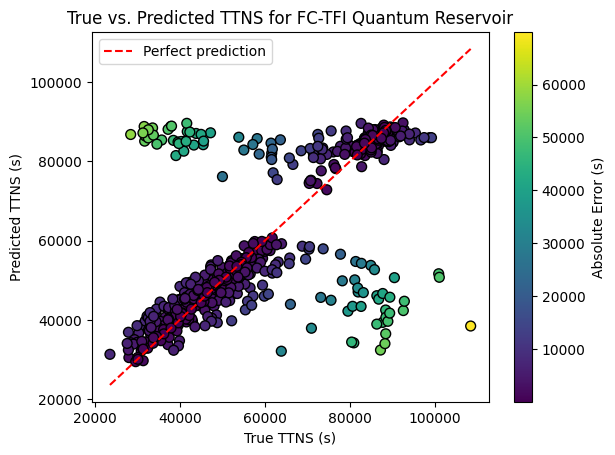


MAE:  8999.88s
RMSE: 16847.43s
R2:   0.3003


In [ ]:
# ── Predicted vs True plot for FC-TFI Quantum Reservoir ──────────────────────
import matplotlib.pyplot as plt
y_test_secs = y_test
QRC_pred_secs = ensemble_pred  # this is the output from run_qrc_pipeline

absolute_error_secs_QRC = np.abs(QRC_pred_secs - y_test_secs)

# Print true vs predicted for every record
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, QRC_pred_secs, absolute_error_secs_QRC)):
    print(f"Sample {i}: True = {true:.0f}s, Predicted = {pred:.0f}s, Error = {abs_error:.0f}s")

# Scatter plot
plt.figure()
plt.scatter(y_test_secs, QRC_pred_secs, c=absolute_error_secs_QRC, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)], 
         color='red', linestyle='--', label='Perfect prediction')
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for FC-TFI Quantum Reservoir")
plt.legend()
plt.show()

print(f"\nMAE:  {mean_absolute_error(y_test_secs, QRC_pred_secs):.2f}s")
print(f"RMSE: {root_mean_squared_error(y_test_secs, QRC_pred_secs):.2f}s")
print(f"R2:   {r2_score(y_test_secs, QRC_pred_secs):.4f}")

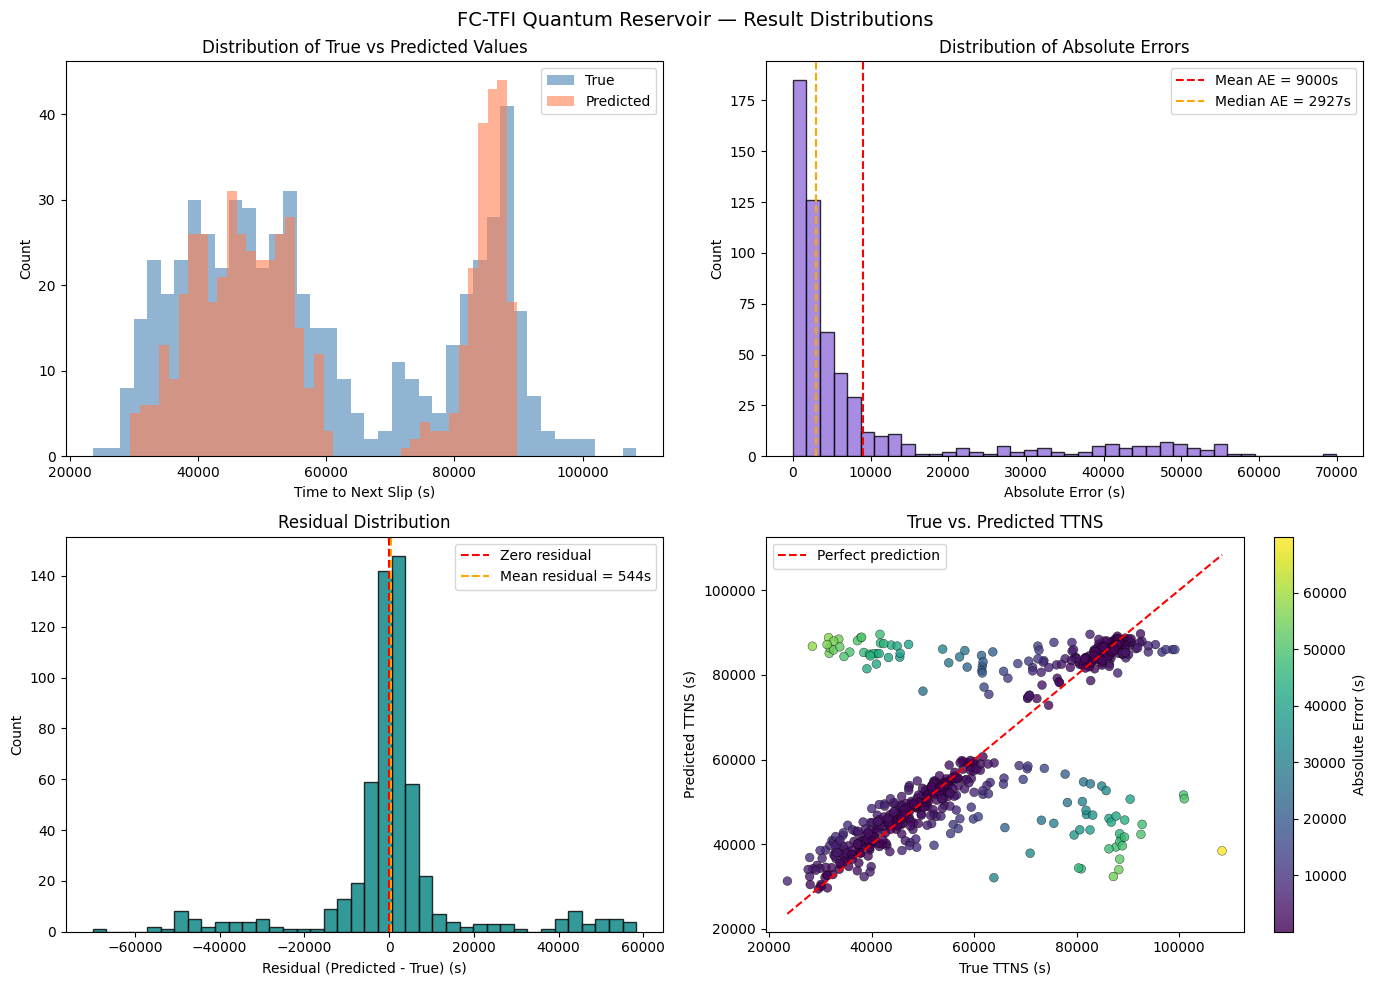

MAE:            8999.88s
Median AE:      2926.99s
RMSE:           16847.43s
R2:             0.3003
Max error:      69917.77s
% within 5000s: 64.6%
% within 9000s: 78.6%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

# ── Data distribution plot for FC-TFI run ────────────────────────────────────
y_test_secs    = y_test
QRC_pred_secs  = ensemble_pred

absolute_errors = np.abs(QRC_pred_secs - y_test_secs)
residuals       = QRC_pred_secs - y_test_secs

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("FC-TFI Quantum Reservoir — Result Distributions", fontsize=14)

# ── Panel 1: Distribution of true vs predicted values ────────────────────────
axes[0, 0].hist(y_test_secs, bins=40, alpha=0.6, color='steelblue', label='True')
axes[0, 0].hist(QRC_pred_secs, bins=40, alpha=0.6, color='coral', label='Predicted')
axes[0, 0].set_xlabel("Time to Next Slip (s)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Distribution of True vs Predicted Values")
axes[0, 0].legend()

# ── Panel 2: Distribution of absolute errors ──────────────────────────────────
axes[0, 1].hist(absolute_errors, bins=40, color='mediumpurple', edgecolor='black', alpha=0.8)
axes[0, 1].axvline(absolute_errors.mean(), color='red', linestyle='--',
                    label=f'Mean AE = {absolute_errors.mean():.0f}s')
axes[0, 1].axvline(np.median(absolute_errors), color='orange', linestyle='--',
                    label=f'Median AE = {np.median(absolute_errors):.0f}s')
axes[0, 1].set_xlabel("Absolute Error (s)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Distribution of Absolute Errors")
axes[0, 1].legend()

# ── Panel 3: Residuals distribution ──────────────────────────────────────────
axes[1, 0].hist(residuals, bins=40, color='teal', edgecolor='black', alpha=0.8)
axes[1, 0].axvline(0, color='red', linestyle='--', label='Zero residual')
axes[1, 0].axvline(residuals.mean(), color='orange', linestyle='--',
                    label=f'Mean residual = {residuals.mean():.0f}s')
axes[1, 0].set_xlabel("Residual (Predicted - True) (s)")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Residual Distribution")
axes[1, 0].legend()

# ── Panel 4: True vs Predicted scatter ───────────────────────────────────────
sc = axes[1, 1].scatter(y_test_secs, QRC_pred_secs,
                         c=absolute_errors, cmap='viridis',
                         s=40, edgecolors='black', linewidths=0.3, alpha=0.8)
plt.colorbar(sc, ax=axes[1, 1], label="Absolute Error (s)")
axes[1, 1].plot([y_test_secs.min(), y_test_secs.max()],
                [y_test_secs.min(), y_test_secs.max()],
                'r--', linewidth=1.5, label='Perfect prediction')
axes[1, 1].set_xlabel("True TTNS (s)")
axes[1, 1].set_ylabel("Predicted TTNS (s)")
axes[1, 1].set_title("True vs. Predicted TTNS")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────────
print(f"MAE:            {mean_absolute_error(y_test_secs, QRC_pred_secs):.2f}s")
print(f"Median AE:      {np.median(absolute_errors):.2f}s")
print(f"RMSE:           {np.sqrt(np.mean(residuals**2)):.2f}s")
print(f"R2:             {r2_score(y_test_secs, QRC_pred_secs):.4f}")
print(f"Max error:      {absolute_errors.max():.2f}s")
print(f"% within 5000s: {(absolute_errors < 5000).mean()*100:.1f}%")
print(f"% within 9000s: {(absolute_errors < 9000).mean()*100:.1f}%")